Nama: Herlinasari\
NIM: 2430109040004\
Mata Kuliah: Analisis Regresi

# import library dan menampilkan data

In [65]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# import dan tampilkan data
df = pd.read_csv('//content/bike sharing.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [66]:
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,12/27/2012,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,12/28/2012,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,12/29/2012,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,12/30/2012,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,12/31/2012,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


# cek tipe data

In [40]:
# cek tipe data semua kolom
print(df.dtypes)

# cek tipe data khusus variabel X dan Y
print("\nTipe data temp:", df['temp'].dtype)
print("Tipe data cnt:", df['cnt'].dtype)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Tipe data temp: float64
Tipe data cnt: int64


# cek missing value dan dibersihkan

In [41]:
# cek missing value
print("\n=== CEK MISSING VALUE ===")
print(df[['temp','cnt']].isnull().sum())

# bersihkan missing value
df = df.dropna(subset=['temp','cnt'])
print("Jumlah data setelah hapus missing value:", len(df))


=== CEK MISSING VALUE ===
temp    0
cnt     0
dtype: int64
Jumlah data setelah hapus missing value: 731


# cek duplikat dan dibersihkan

In [42]:
#cek duplikat
print("\n=== CEK DUPLIKAT ===")
print("Jumlah duplikat:", df.duplicated().sum())

# hapus duplikat
df = df.drop_duplicates()
print("Jumlah data setelah hapus duplikat:", len(df))


=== CEK DUPLIKAT ===
Jumlah duplikat: 0
Jumlah data setelah hapus duplikat: 731


# cek outlier dan dibersihkan


=== CEK OUTLIER (IQR) ===
Jumlah outlier temp: 0
Jumlah outlier cnt: 0
Jumlah total baris yang mengandung outlier: 0


/tmp/ipykernel_4139/896734678.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['temp'], df['cnt']], labels=['temp', 'cnt'])


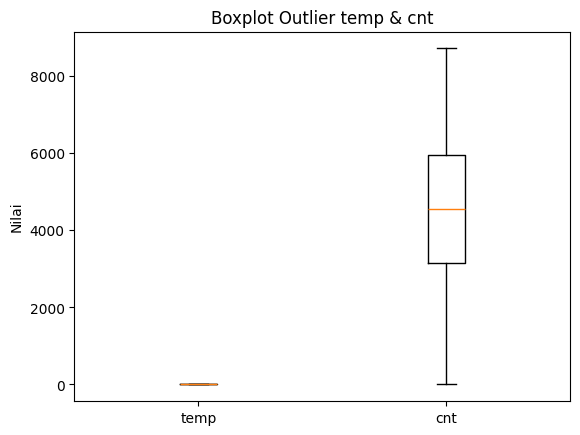


Jumlah data SETELAH bersihkan outlier: 731

=== PREVIEW DATA BERSIH ===
   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  1/1/2011       1   0     1        0        6           0   
1        2  1/2/2011       1   0     1        0        0           0   
2        3  1/3/2011       1   0     1        0        1           1   
3        4  1/4/2011       1   0     1        0        2           1   
4        5  1/5/2011       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   8

In [43]:
#cek outlier data
print("\n=== CEK OUTLIER (IQR) ===")

Q1 = df[['temp','cnt']].quantile(0.25)
Q3 = df[['temp','cnt']].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# deteksi outlier
outlier_bool = (df[['temp','cnt']] < lower) | (df[['temp','cnt']] > upper)

print("Jumlah outlier temp:", outlier_bool['temp'].sum())
print("Jumlah outlier cnt:", outlier_bool['cnt'].sum())
print("Jumlah total baris yang mengandung outlier:", outlier_bool.any(axis=1).sum())

# Plot Outlier (BOXPLOT)
plt.figure()
plt.boxplot([df['temp'], df['cnt']], labels=['temp', 'cnt'])
plt.title("Boxplot Outlier temp & cnt")
plt.ylabel("Nilai")
plt.show()

# Bersihkan Outlier
df_clean = df[~outlier_bool.any(axis=1)]

print("\nJumlah data SETELAH bersihkan outlier:", len(df_clean))
print("\n=== PREVIEW DATA BERSIH ===")
print(df_clean.head())

# standarisasi (z-score)

In [44]:
# standarisasi z-score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_scaled = df_clean.copy()
df_scaled[['temp', 'cnt']] = scaler.fit_transform(df_clean[['temp', 'cnt']])

print("\n=== Data Setelah Z-Score ===")
print(df_scaled[['temp','cnt']].head())



=== Data Setelah Z-Score ===
       temp       cnt
0 -0.826662 -1.817953
1 -0.721095 -1.912999
2 -1.634657 -1.629925
3 -1.614780 -1.519898
4 -1.467414 -1.500269


# Plot Regresi

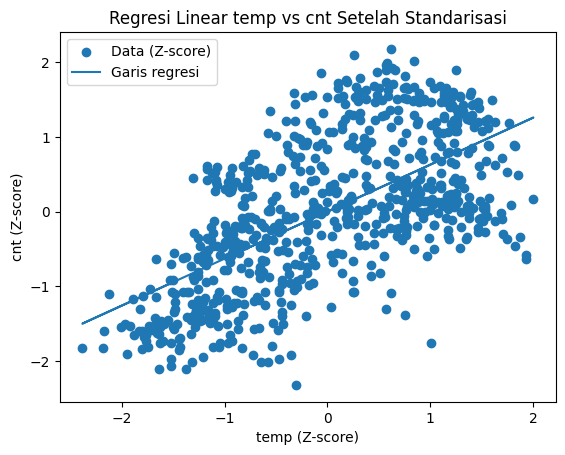

In [45]:
# plot
m, b = np.polyfit(df_scaled['temp'], df_scaled['cnt'], 1)

plt.figure()
plt.scatter(df_scaled['temp'], df_scaled['cnt'], label="Data (Z-score)")

# garis regresi
plt.plot(df_scaled['temp'], m * df_scaled['temp'] + b, label="Garis regresi")

plt.xlabel('temp (Z-score)')
plt.ylabel('cnt (Z-score)')
plt.title('Regresi Linear temp vs cnt Setelah Standarisasi')
plt.legend()
plt.show()

# statistik deskriptis

In [46]:
print("=== Statistik Deskriptif Variabel temp dan cnt ===")

# mean
print("Mean:")
print(df_clean[['temp','cnt']].mean(), "\n")

# median
print("Median:")
print(df_clean[['temp','cnt']].median(), "\n")

# standar deviasi
print("Standar Deviasi:")
print(df_clean[['temp','cnt']].std(), "\n")

# nilai minimum
print("Minimum:")
print(df_clean[['temp','cnt']].min(), "\n")

# nilai maksimum
print("Maksimum:")
print(df_clean[['temp','cnt']].max(), "\n")

# IQR (Interquartile Range)
Q1 = df_clean[['temp','cnt']].quantile(0.25)
Q3 = df_clean[['temp','cnt']].quantile(0.75)
IQR = Q3 - Q1

print("IQR (Interquartile Range):")
print(IQR)

=== Statistik Deskriptif Variabel temp dan cnt ===
Mean:
temp       0.495385
cnt     4504.348837
dtype: float64 

Median:
temp       0.498333
cnt     4548.000000
dtype: float64 

Standar Deviasi:
temp       0.183051
cnt     1937.211452
dtype: float64 

Minimum:
temp     0.05913
cnt     22.00000
dtype: float64 

Maksimum:
temp       0.861667
cnt     8714.000000
dtype: float64 

IQR (Interquartile Range):
temp       0.318333
cnt     2804.000000
dtype: float64


# Analisis Korelasi (Pearson)

In [58]:
from scipy.stats import pearsonr
import numpy as np

# Ambil variabel
x = df_clean['temp']
y = df_clean['cnt']

# Hitung korelasi Pearson
r, p_value = pearsonr(x, y)
n = len(df_clean)

# Hitung R^2
r_squared = r ** 2

# Interpretasi kekuatan hubungan
print("=== Analisis Korelasi Pearson ===")
print(f"Koefisien Korelasi (r): {r:.4f}")
print(f"R^2: {r_squared:.4f}")
print(f"Jumlah data (n): {n}")
print(f"P-value: {p_value:.6f}")

# Kekuatan korelasi
print("\nInterpretasi Kekuatan Korelasi:")
if abs(r) < 0.3:
    print("Hubungan sangat lemah.")
elif abs(r) < 0.5:
    print("Hubungan lemah.")
elif abs(r) < 0.7:
    print("Hubungan sedang.")
elif abs(r) < 0.9:
    print("Hubungan kuat.")
else:
    print("Hubungan sangat kuat.")

# Hitung t-statistik
t_stat = r * np.sqrt((n - 2) / (1 - r**2))
print(f"\nt-statistic: {t_stat:.4f}")

# Uji Hipotesis
alpha = 0.05
print("\nInterpretasi Uji Signifikansi (α = 0.05):")
if p_value < alpha:
    print("H0 ditolak → hubungan signifikan antara temperature dan rental count.")
else:
    print("H0 gagal ditolak → tidak ada hubungan signifikan antara temperature dan rental count.")

=== Analisis Korelasi Pearson ===
Koefisien Korelasi (r): 0.6275
R^2: 0.3937
Jumlah data (n): 731
P-value: 0.000000

Interpretasi Kekuatan Korelasi:
Hubungan sedang.

t-statistic: 21.7594

Interpretasi Uji Signifikansi (α = 0.05):
H0 ditolak → hubungan signifikan antara temperature dan rental count.


# Regresi Linear

In [59]:
import numpy as np

x = df_clean['temp']
y = df_clean['cnt']

m, b = np.polyfit(x, y, 1)

print("Intercept (a):", round(b,3))
print("Slope (b):", round(m,3))

print("Persamaan regresi:")
print("ŷ =", round(b,3), "+", round(m,3), "x")

Intercept (a): 1214.642
Slope (b): 6640.71
Persamaan regresi:
ŷ = 1214.642 + 6640.71 x


# Scatter Plot dengan Garis Regresi Linear

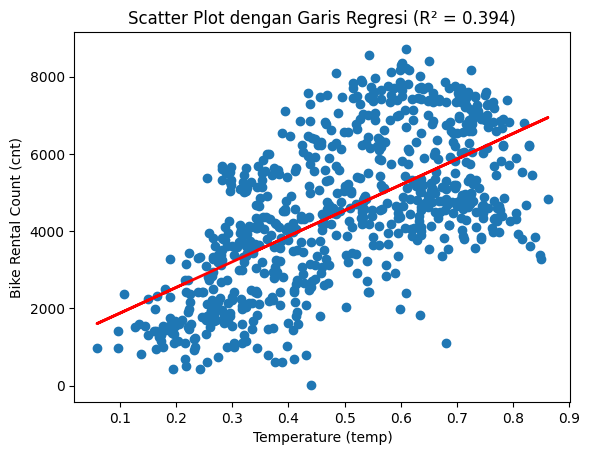

In [60]:
import matplotlib.pyplot as plt
import numpy as np

x = df_clean['temp']
y = df_clean['cnt']

# hitung garis regresi
m, b = np.polyfit(x, y, 1)

plt.figure()

# scatter plot
plt.scatter(x, y)

# garis regresi
plt.plot(x, m*x + b, color='red', linewidth=2)

plt.xlabel("Temperature (temp)")
plt.ylabel("Bike Rental Count (cnt)")
plt.title(f"Scatter Plot dengan Garis Regresi (R² = {r_squared:.3f})")

plt.show()

# Uji Asumsi Klasik

Uji Normalitas

=== Uji Normalitas Shapiro-Wilk ===
Statistik: 0.9867085471625606
P-value: 3.392432522627428e-06

Interpretasi:
P-value = 0.0000 < 0.05 → H0 ditolak.
Residual tidak berdistribusi normal (asumsi normalitas tidak terpenuhi).


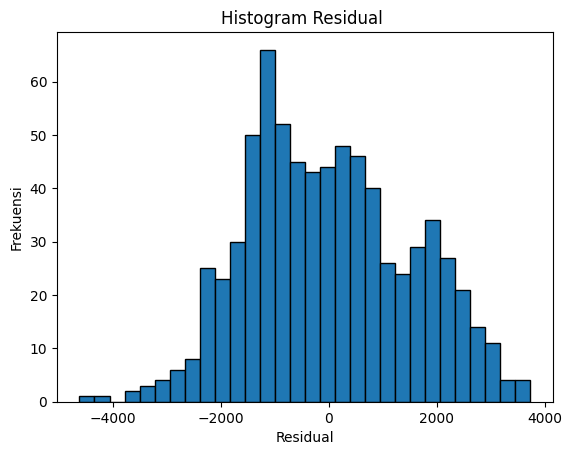

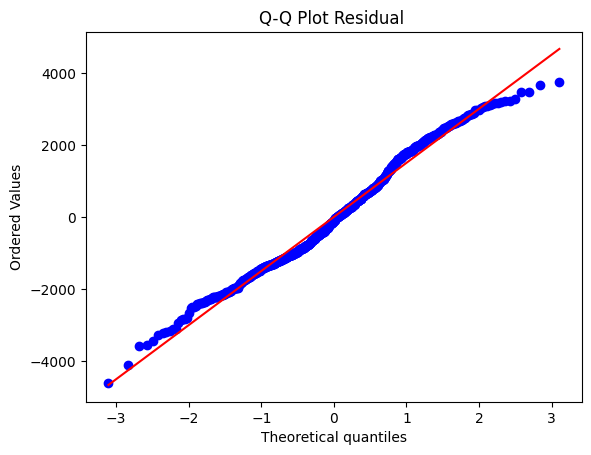

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

# Hitung residual dari model regresi
y_pred = m * df_clean['temp'] + b
residual = df_clean['cnt'] - y_pred

# Uji Normalitas Shapiro-Wilk
stat, p_value = shapiro(residual)

print("=== Uji Normalitas Shapiro-Wilk ===")
print("Statistik:", stat)
print("P-value:", p_value)

# Interpretasi
alpha = 0.05
print("\nInterpretasi:")

if p_value > alpha:
    print(f"P-value = {p_value:.4f} > {alpha} → H0 diterima.")
    print("Residual berdistribusi normal (asumsi normalitas terpenuhi).")
else:
    print(f"P-value = {p_value:.4f} < {alpha} → H0 ditolak.")
    print("Residual tidak berdistribusi normal (asumsi normalitas tidak terpenuhi).")

# histogram distribusi
plt.figure()
plt.hist(residual, bins=30, edgecolor='black')
plt.title("Histogram Residual ")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.show()

# QQ Plot distribusi
plt.figure()
probplot(residual, plot=plt)
plt.title("Q-Q Plot Residual ")
plt.show()

Uji Homoskedastisitas (Breusch-Pagan Test )

=== UJI HETEROSKEDASTISITAS BREUSCH–PAGAN ===
BP Statistic: 9.5279
P-value: 0.002023734056314193
Kesimpulan: Terdapat heteroskedastisitas (varian residual tidak homogen).


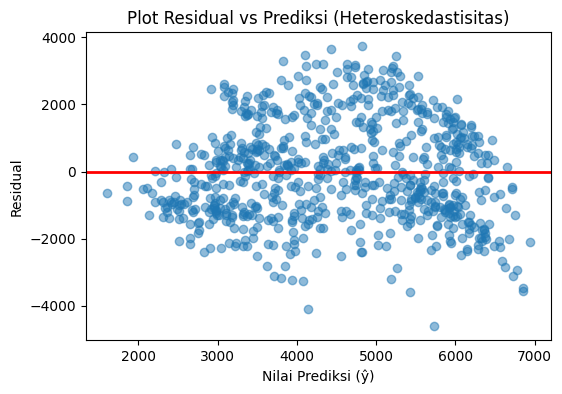

In [63]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt

# variabel X dan Y
X = df_clean['temp']
y = df_clean['cnt']

# tambahkan konstanta untuk model OLS
X_ols = sm.add_constant(X)

# fit model
model = sm.OLS(y, X_ols).fit()

# residual & prediksi
residual = model.resid
y_pred = model.predict(X_ols)
# Breusch-Pagan Test
bp_test = het_breuschpagan(residual, model.model.exog)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("=== UJI HETEROSKEDASTISITAS BREUSCH–PAGAN ===")
print("BP Statistic:", round(bp_stat, 4))
print("P-value:", bp_pvalue)

alpha = 0.05

if bp_pvalue > alpha:
    print("Kesimpulan: Tidak ada heteroskedastisitas (varian residual homogen).")
else:
    print("Kesimpulan: Terdapat heteroskedastisitas (varian residual tidak homogen).")

# Plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residual, alpha=0.5)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel("Nilai Prediksi (ŷ)")
plt.ylabel("Residual")
plt.title("Plot Residual vs Prediksi (Heteroskedastisitas)")
plt.show()

Uji Linearitas

Korelasi residual vs y_pred = 0.0
Interpretasi: linear (tidak ada pola melengkung yang signifikan)


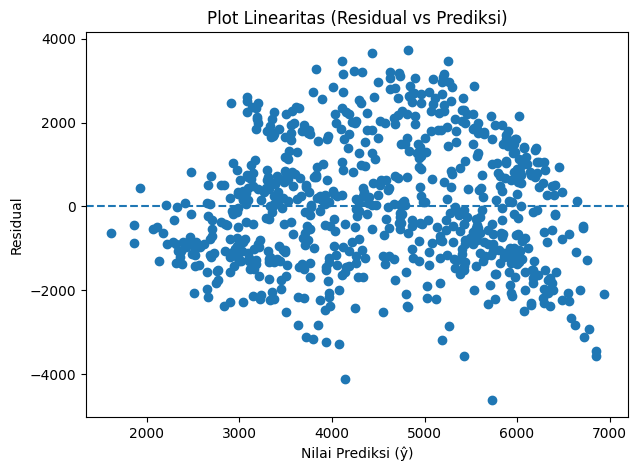

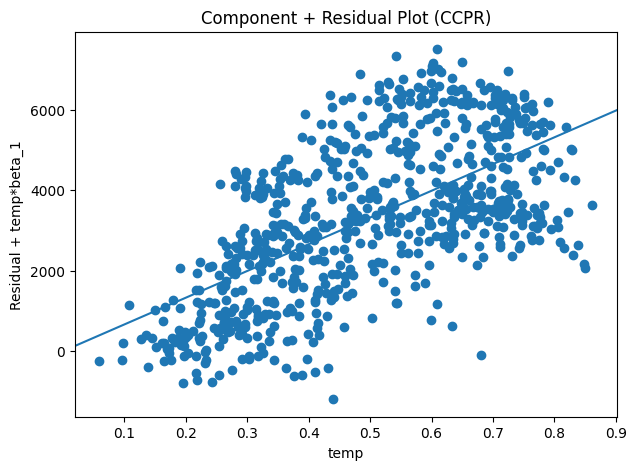

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro

# Residual & prediksi
X = df_clean['temp']
y = df_clean['cnt']
y_pred = model.predict(X_ols)
residual = y - y_pred

# Interpretasi
corr = np.corrcoef(y_pred, residual)[0,1]

if abs(corr) < 0.2:
    linearitas = "linear (tidak ada pola melengkung yang signifikan)"
else:
    linearitas = "mungkin TIDAK linear (ada pola hubungan antara prediksi dan residual)"

print("Korelasi residual vs y_pred =", round(corr, 3))
print("Interpretasi:", linearitas)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residual)
plt.axhline(0, linestyle='--')
plt.xlabel("Nilai Prediksi (ŷ)")
plt.ylabel("Residual")
plt.title("Plot Linearitas (Residual vs Prediksi)")
plt.show()

# Component plus Residual (CR Plot)
fig, ax = plt.subplots(figsize=(7,5))
sm.graphics.plot_ccpr(model, 1, ax=ax)   # 1 = indeks variabel X ke-1 (temp)
plt.title("Component + Residual Plot (CCPR)")
plt.show()

Uji Autokorelasi (Durbin-Watson)

=== Durbin–Watson Test ===
Nilai Durbin–Watson: 0.46787071154421833
Interpretasi: Ada autokorelasi positif.


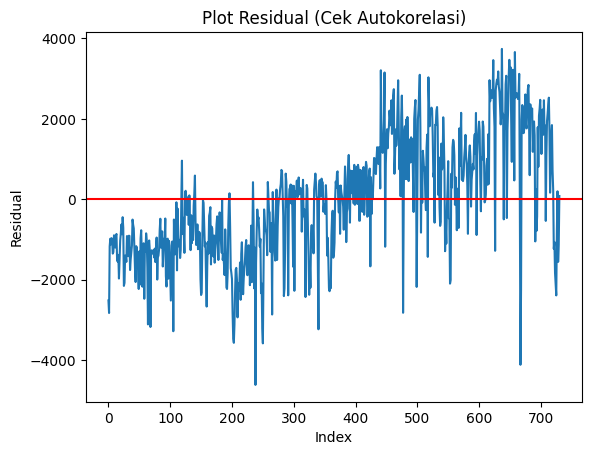

In [57]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual)

print("=== Durbin–Watson Test ===")
print("Nilai Durbin–Watson:", dw)

# Interpretasi otomatis
if 1.5 <= dw <= 2.5:
    print("Interpretasi: Tidak ada autokorelasi.")
elif dw < 1.5:
    print("Interpretasi: Ada autokorelasi positif.")
else:
    print("Interpretasi: Ada autokorelasi negatif.")

# Plot residual berurutan
plt.figure()
plt.plot(residual)
plt.axhline(0, color='red')
plt.title("Plot Residual (Cek Autokorelasi)")
plt.xlabel("Index")
plt.ylabel("Residual")
plt.show()